# Character Counts

In [1]:
import pandas as pd
import csv
from collections import Counter
import unicodedata
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

In [2]:
# find which rows are duplicated
def dup_rows(df):
    print(f'Original Length: {len(df)}')
    dup_sentences = df.duplicated(subset='sentence', keep=False)
    dup_indices = dup_sentences[dup_sentences == True]
    print(f'{len(dup_indices)} TOTAL DUPLICATES FOUND')
    for i in dup_indices.index:
        print(f'{i}: {df.loc[i]}')
    dropped = df.drop_duplicates(subset='sentence',keep='first')
    print(f'New Length: {len(dropped)}')
    return dropped


In [3]:
# read in the datasets in my preferred format
def load_dataset(filename):
    return pd.read_csv(filename, header=0, index_col=0)

def save_counter_csv(c, filename):
    with open(filename, 'w') as f:
        writer = csv.writer(f)
        for char_row in c.most_common():
            writer.writerow(char_row)

In [4]:
# diacritics as their unicode value
LOTONE = chr(0x0300)
HITONE = chr(0x0301)
RISETONE = chr(0x030C)
MIDTONE1 = chr(0x0304)
MIDTONE2 = chr(0x0305)
TONECHARS = {LOTONE, HITONE, RISETONE,MIDTONE1,MIDTONE2}

UNDERDOT = chr(0x0323)
UNDERLINE = chr(0x0329)
UNDERDIACS = {UNDERDOT, UNDERLINE}

# split characters into letters (with their diacritics)
def get_letters(text):
    try:
        text = unicodedata.normalize('NFD', text)
    except:
        print(text)
        return []
    text = text.replace(UNDERLINE, UNDERDOT)
    letters = []
    i = 0
    while i < len(text):
        curr_letter = ''
        # look for gb
        if ((i+1) < len(text) and ((text[i] == 'g') and (text[i+1] == 'b'))):
            curr_letter = text[i:i+2]
            i+=2

        # check if next char exists and is a diacritic
        elif ((i+1) < len(text)) and ((text[i+1] in TONECHARS) or text[i+1] in UNDERDIACS):
            if ((i+2) < len(text) and ((text[i+2] in TONECHARS) or text[i+2] in UNDERDIACS)):
                curr_letter = text[i:i+3]
                # print(f"{text[i:i+3]}\t{text[max(i-4, 0):i+4]}\t{text}")
                i+=3 # skip next two chars
            else:
                curr_letter = text[i:i+2]
                i+=2 # skip next char
                
        # normal case (the letter is one single char)
        else: 
            curr_letter = text[i]
            i+=1 # go to next char
        
        # add letter to list
        letters.append(curr_letter.lower())
    return letters

# count all characters
def all_chars(df):
    c = Counter(get_letters(df.iloc[0].loc['sentence']))
    for sentence in df['sentence']:
        c.update(get_letters(sentence))
    return c

In [10]:
# re-calculate letter counts
df = load_dataset('/Users/graven2/Documents/THESIS/data/iroyinspeech_full2_CLEAN.csv')
print(len(df))
df = dup_rows(df)
print(len(df))
#df.to_csv('/Users/graven2/Documents/THESIS/data/yad_full_CLEAN.csv')
c = all_chars(df)
#save_counter_csv(c, 'character_count_yad_CLEAN.csv')

26683
Original Length: 26683
0 TOTAL DUPLICATES FOUND
New Length: 26683
26683


In [2]:
# display char counts
df_iroyin = pd.read_csv('/Users/graven2/Documents/THESIS/YorubaThesis/EDA/data/character_count_iroyin_CLEAN.csv', header=0)
df_multidiac = pd.read_csv('/Users/graven2/Documents/THESIS/YorubaThesis/EDA/data/character_count_multidiac_CLEAN.csv', header=0)
df_yad = pd.read_csv('/Users/graven2/Documents/THESIS/YorubaThesis/EDA/data/character_count_yad_CLEAN.csv', header=0)


In [3]:
# get all character counts
df_iroyin_alpha = df_iroyin[df_iroyin['char'].str[0].str.isalpha()].rename(columns={'count':'count_iroyin'})
df_multidiac_alpha = df_multidiac[df_multidiac['char'].str[0].str.isalpha()].rename(columns={'count': 'count_multidiac'})
df_yad_alpha = df_yad[df_yad['char'].str[0].str.isalpha()].rename(columns={'count': 'count_yad'})

# combine them
orig_merged = pd.merge(df_iroyin_alpha, df_multidiac_alpha, on='char', how='outer')
orig_merged = pd.merge(orig_merged, df_yad_alpha, on='char', how='outer')

# replace NaN with 0
orig_merged = orig_merged.fillna(0)

# filter out small numbers
merged = orig_merged[(orig_merged['count_iroyin'] > 30) | (orig_merged['count_iroyin'] == 0)]
# merged = merged[(merged['count_multidiac'] > 1) | (merged['count_multidiac'] == 0)] # small dataset, no need to filter
merged = merged[(merged['count_yad'] > 30) | (merged['count_yad'] == 0)]
merged['count_total'] = merged[['count_iroyin', 'count_multidiac', 'count_yad']].sum(axis=1)

# normalize to percentage
def norm_column(df, col_name):
    return ((df[col_name]/df[col_name].sum()) * 100)

merged['norm_iroyin'] = norm_column(merged, 'count_iroyin')
merged['norm_multidiac'] = norm_column(merged, 'count_multidiac')
merged['norm_yad'] = norm_column(merged, 'count_yad')
merged['norm_total'] = norm_column(merged, 'count_total')

In [4]:
display(merged)

,char,count_iroyin,count_multidiac,count_yad,count_total,norm_iroyin,norm_multidiac,norm_yad,norm_total
0,a,40588.0,963.0,44731.0,86282.0,3.792605,5.587467,4.180159,3.999162
1,à,59828.0,797.0,57747.0,118372.0,5.590420,4.624311,5.396517,5.486530
4,á,41369.0,723.0,41165.0,83257.0,3.865582,4.194952,3.846912,3.858954
10,b,24480.0,426.0,22284.0,47190.0,2.287449,2.471715,2.082463,2.187252
12,d,22197.0,371.0,20222.0,42790.0,2.074122,2.152596,1.889767,1.983312
14,e,11743.0,304.0,15341.0,27388.0,1.097284,1.763853,1.433632,1.269431
15,è,15623.0,137.0,17354.0,33114.0,1.459837,0.794894,1.621749,1.534831
17,é,22396.0,234.0,19563.0,42193.0,2.092716,1.357702,1.828183,1.955641
19,ẹ,12613.0,354.0,11636.0,24603.0,1.178578,2.053960,1.087396,1.140347
20,ẹ̀,17450.0,212.0,19617.0,37279.0,1.630555,1.230055,1.833229,1.727878


In [8]:
def graph_letterfreq(df, title):
    # graph it
    plt.figure(figsize=(18,6))

    df = df.sort_values('norm_total', ascending=False)

    # set up x vals
    chars = df['char'] # all x labels
    x = np.arange(0, len(chars) * 1.5, 1.5) # x positions for each char
    width=0.75 # width of each bar
    x = x * (4*width) # add space between each group
    # print(x)

    plt.bar(x - 1.5*width, df['norm_total'], width=width, label='Combined Datasets')
    plt.bar(x - 0.5*width, df['norm_iroyin'], width=width, label='IroyinSpeech')
    plt.bar(x + 0.5*width, df['norm_multidiac'], width=width, label='MultiDiac')
    plt.bar(x + 1.5*width, df['norm_yad'], width=width, label='YAD')

    # add labels and legend
    plt.xlabel('Character')
    plt.ylabel('Frequency (%)')
    plt.title(title)
    plt.xticks(x, chars)  # x axis labels
    plt.xlim((0-2.5*width, x[len(x) -1] + 2.5*width)) # get nicer x axis limits
    prop = FontProperties()
    prop.set_file('Roboto-VariableFont_wdth,wght.ttf')
    plt.legend()

    plt.show()

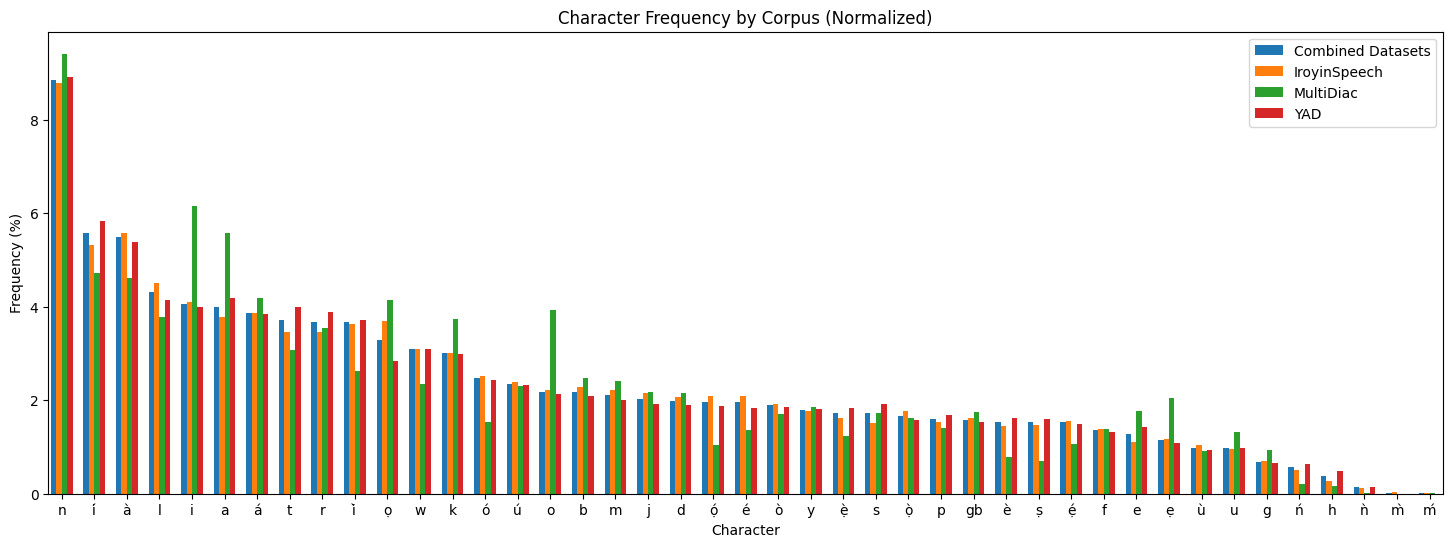

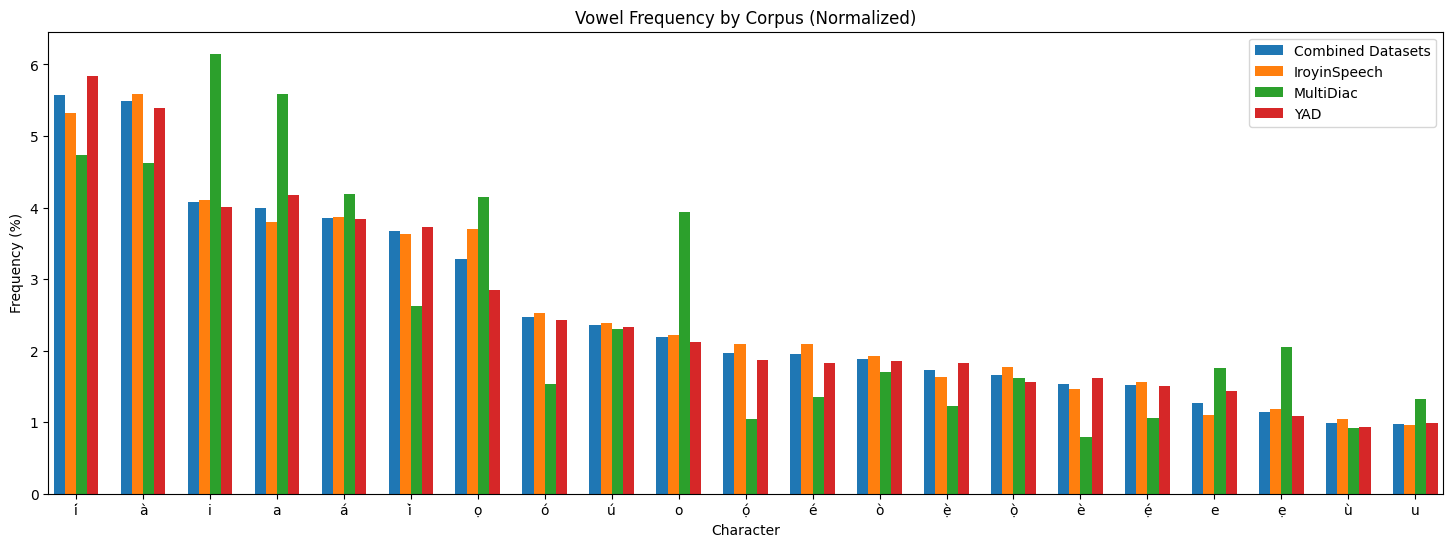

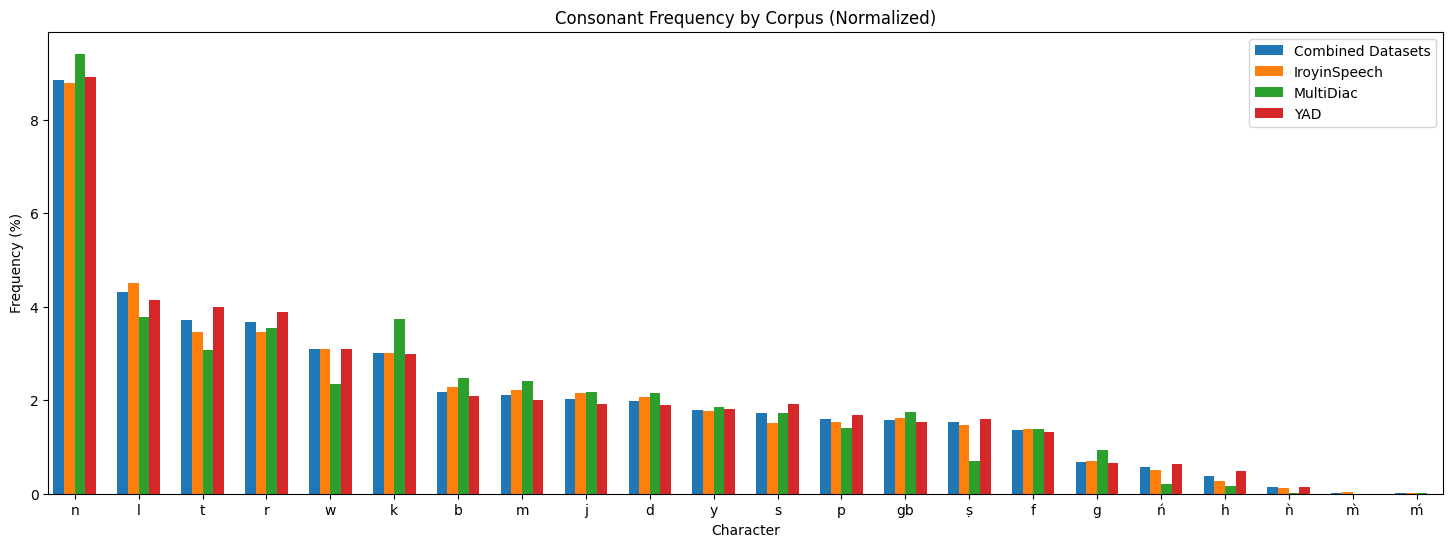

In [10]:
graph_letterfreq(merged, 'Character Frequency by Corpus (Normalized)')

vowels = ['a', 'e', 'i', 'o', 'u']
vowel_df = merged[merged['char'].str[0].isin(vowels)]
graph_letterfreq(vowel_df, 'Vowel Frequency by Corpus (Normalized)')

consonant_df = merged[~merged['char'].str[0].isin(vowels)]
graph_letterfreq(consonant_df, 'Consonant Frequency by Corpus (Normalized)')

In [54]:
# get correlation between datasets
correlations = merged[['count_iroyin', 'count_multidiac', 'count_yad']].corr()
print(correlations)

correlations = orig_merged[['count_iroyin', 'count_multidiac', 'count_yad']].corr()
print(correlations)

                 count_iroyin  count_multidiac  count_yad
count_iroyin         1.000000         0.926514   0.989114
count_multidiac      0.926514         1.000000   0.918307
count_yad            0.989114         0.918307   1.000000
                 count_iroyin  count_multidiac  count_yad
count_iroyin         1.000000         0.961888   0.994782
count_multidiac      0.961888         1.000000   0.957835
count_yad            0.994782         0.957835   1.000000


# Remove Illegal Rows

In [34]:
legal_cons = ['b', 't', 'd', 'j', 'k', 'g', 'gb', 'p', 'm', 'n', 'f', 's', 'l', 'r', 'h', 'w', 'y', 'd']
legal_vows = ['i', 'e', 'a', 'o', 'u']
legal_chars = legal_cons + legal_vows

df = load_dataset('/Users/graven2/Documents/THESIS/data/yad_full.csv')

rm_index = set() # store all indexes to remove
# iterate through all sentences
for index, data in df.iterrows():
    sentence = data['sentence']
    letters = get_letters(sentence)
    for letter in letters:
        char = letter[0]

        # check if it's a letter
        if char.isalpha():
            # if char == 'v': print(char)
            # remove any illegal charactesr
            if char in legal_chars: continue
            else: 
                print(char)
                rm_index.add(index)


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [36]:
print(len(df))

16394


In [37]:
print(rm_index)
df = df.drop(rm_index)
print(len(df))


set()
16394


# Word Counts

In [11]:
def load_dataset(filename):
    return pd.read_csv(filename, header=0, index_col=0)

In [47]:
iroyin = load_dataset('/Users/graven2/Documents/THESIS/data/iroyinspeech_full2_deduped.csv')
multidiac = load_dataset('/Users/graven2/Documents/THESIS/data/multidiac_full.csv')
yad = load_dataset('/Users/graven2/Documents/THESIS/data/yad_full_CLEAN.csv')
yad['sentence'] = yad['sentence'].astype(str)

In [48]:
all_data = pd.DataFrame(columns=['Source', 'ID', 'Sentence'])
print('---IROYIN---')
for index, row in iroyin.iterrows():
    all_data.loc[len(all_data)] = ['IroyinSpeech', index, row['sentence']]

print('---MultiDiac---')
for index, row in multidiac.iterrows():
    all_data.loc[len(all_data)] = ['MultiDiac', index, row['sentence']]

print('---YAD---')
for index, row in yad.iterrows():
    all_data.loc[len(all_data)] = ['YAD', index, row['sentence']]

def dup_rows(df):
    print(f'Original Length: {len(df)}')
    dup_sentences = df.duplicated(subset='Sentence', keep=False)
    dup_indices = dup_sentences[dup_sentences == True]
    print(f'{len(dup_indices)} TOTAL DUPLICATES FOUND')
    for i in dup_indices.index:
        print(f'{i}: {df.loc[i]}')
    dropped = df.drop_duplicates(subset='Sentence',keep='first')
    print(f'New Length: {len(dropped)}')
    return dropped

deduped = dup_rows(all_data)

---IROYIN---
---MultiDiac---
---YAD---
Original Length: 43494
48 TOTAL DUPLICATES FOUND
249: Source                                           IroyinSpeech
ID                                                  00250.wav
Sentence    A ti gbé ìgbésẹ̀ láti bá àwọn tí ọ̀rọ̀ náà kàn...
Name: 249, dtype: object
253: Source                                           IroyinSpeech
ID                                                  00254.wav
Sentence    A ó túbọ̀ máa fọwọ́sowọ̀pọ́ pẹ̀lú ìjọba ìpínlẹ...
Name: 253, dtype: object
278: Source                                           IroyinSpeech
ID                                                  00279.wav
Sentence    Ọjọ́ kẹ́rìnlélógún, oṣú kejìlá, ọdún yìí ní il...
Name: 278, dtype: object
312: Source                                           IroyinSpeech
ID                                                  00313.wav
Sentence    Ó tún wá dúpẹ́ lọ́wọ́ ilé ìgbìmọ̀ asòfin fún à...
Name: 312, dtype: object
2133: Source                                   I

In [44]:
import re

In [49]:
def get_wc(df, col_name):
    df[f'normalized_{col_name}'] = df[col_name].apply(lambda x: re.sub(r'[0-9]', '0', x))
    
    # Word count per row
    df['word_count'] = df[f'normalized_{col_name}'].apply(lambda x: len(x.lower().split()))

    # # Unique words per row
    # df['unique_words_per_row'] = df['text'].apply(lambda x: len(set(x.split())))

    # All unique words across the entire column
    all_words = df[col_name].str.split().explode()
    unique_words = set(all_words)

    # # Word frequency across the entire column
    # word_freq = Counter(all_words)

    print(f"Total words: {df['word_count'].sum()}\n")
    print(f"Unique words: {len(unique_words)}\n")

    return df


In [50]:
print('IROYIN')
iroyin = get_wc(iroyin, 'sentence')
print('MULTIDIAC')
multidiac = get_wc(multidiac, 'sentence')
print('YAD')
yad = get_wc(yad, 'sentence')
print('TOTAL')
deduped = get_wc(deduped, 'Sentence')

IROYIN
Total words: 301571

Unique words: 28913

MULTIDIAC
Total words: 5490

Unique words: 1730

YAD
Total words: 305258

Unique words: 32632

TOTAL
Total words: 612061

Unique words: 54525



/var/folders/nx/n0bhmnq56qs0j8dw9w1xnwmm0000gp/T/ipykernel_70597/4120192754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'normalized_{col_name}'] = df[col_name].apply(lambda x: re.sub(r'[0-9]', '0', x))
/var/folders/nx/n0bhmnq56qs0j8dw9w1xnwmm0000gp/T/ipykernel_70597/4120192754.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df[f'normalized_{col_name}'].apply(lambda x: len(x.lower().split()))
